In [17]:
"""This code takes some time to run due to the high number of sampled data points
Decrease T = 1000000 for quicker but less accurate empirical PDF
or reduce the number of eval_points from 1000 e.g. to 100"""

#importing useful libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

#getting current directory
import os
cwd = os.getcwd()

#importing all the functions contained in "functions.py"
%run ../functions

In [3]:
#time lengths
delta_t = 0.3 
T = 1000000

#define parameters of the three-state model
V = np.array([2000, -1500])
Lambda = np.array([1, 0.5])
P = np.array([[0.0, 1.0], [1.0, 0.0]])
sigma = 50
n = Lambda.shape[0]

#running the model
x_sim, y_sim, t_sim, sw, st = n_state_model(delta_t, T, V, Lambda, P, sigma)

#constructing the increments
delta_y = np.array([y_sim[i]-y_sim[i-1] for i in range(1, len(y_sim))])

#define points for which we need the PDF approximation    
eval_points = np.linspace(np.min(delta_y), np.max(delta_y), 1000)

#compute the PDF approximation - up-to-one-switch
approx_pdf_res = approx_pdf_up_to_1_switch(V, Lambda, P, sigma, delta_t, eval_points)

#compute the PDF approximation - up-to-two-switch
#approx_pdf_res_2 = approx_pdf_up_to_2_switch(V, Lambda, P, sigma, delta_t, eval_points)

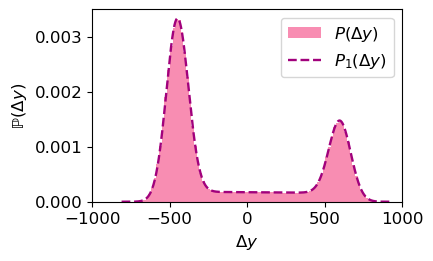

In [43]:
colors_list = mpl.colormaps['RdPu'](np.linspace(0, 1, 10))

plt.figure(figsize=(4,2.5))
plt.hist(delta_y, bins=100, density=True, color=colors_list[-6], alpha=0.9, label=r'$P(\Delta y)$')
plt.plot(eval_points, approx_pdf_res, '--', color=colors_list[-3], linewidth=1.7, label=r'$P_1(\Delta y)$')
plt.xlabel(r'$\Delta y$', fontsize=12)
plt.ylabel(r'$\mathrm{\mathbb{P}}(\Delta y)$', fontsize=12)
plt.xlim([-1000,1000])
plt.yticks([0.000, 0.001, 0.002, 0.003], fontsize=12)
plt.xticks([-1000, -500, 0, 500, 1000], fontsize=12)
#plt.title(r'$P(\Delta y)$ vs approximation $P_1(\Delta y)$', fontsize=12)
plt.legend(fontsize=12)
plt.savefig("PDF_comparison.png", format="png", dpi=1200, bbox_inches="tight") 